### 工作進度  
* **新的筆記內容架構**與**量化技術分析系統**相關資訊請參閱[250801筆記.ipynb](https://github.com/yilintung/StockInvestmentNotebook/blob/main/250801%E7%AD%86%E8%A8%98.ipynb)之工作進度。  
* 本日「K線追擊週報」LINE群組日報：[楊忠憲K線追擊週報_250805日報.docx](https://mega.nz/file/m0QSnbCB#hFsyA8sRrwzTV-UOdEmtZhnFoUsbKYyGBdhFibJDCXc)。  

* 引入模組與定義公用函式  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

* 更新量化技術分析資料庫  

In [3]:
mysys.UpdatestockDatabase()

2025-08-05 21:47:46.979 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockInfo, data_id: 


##### 更新台股總覽 #####
##### 更新技術分析資料 #####


2025-08-05 21:47:49.624 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:48:18.967 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:48:23.934 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:48:53.541 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:48:58.867 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:49:30.214 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:49:35.443 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:50:06.807 | INFO     | FinMind.data.finmind_api:get_data:155 - download TaiwanStockPrice, data_id: 
2025-08-05 21:50:12.157 | INFO     | FinMind.data.finmind_api:get_data:155 - download Ta

日K：2025-08-05


* 建立「解盤」物件    

In [4]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

> **盤中**：持續多方的整理型態。  
> 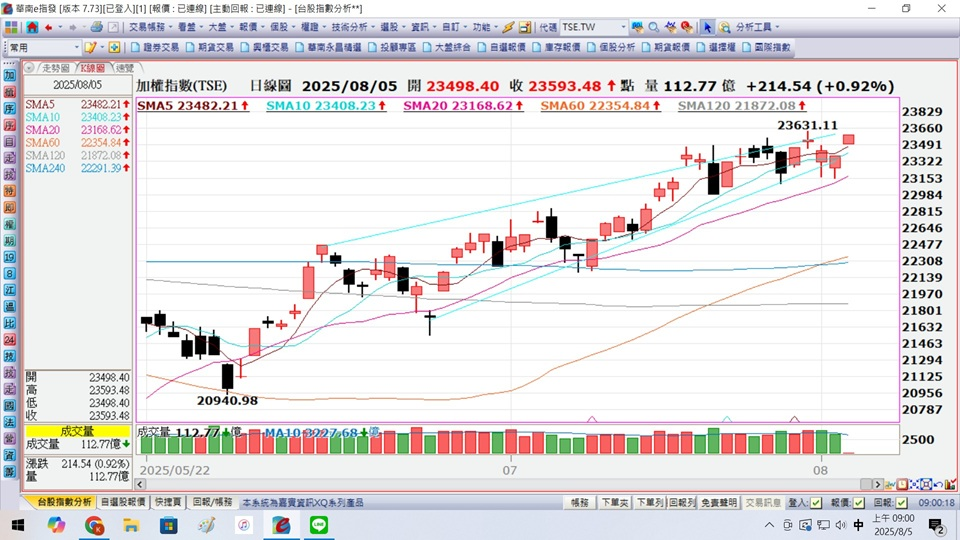    

In [5]:
# 上升楔形
def line_drawing_callback( range_prices) :

    seq_of_seq_of_points = []
    linewidths           = []
    colors               = []

    # 設定楔形壓力線
    resistance_line_start_date  = '2025-06-11'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.DateToIndex(range_prices,'2025-06-11'),mysys.DateToIndex(range_prices,'2025-07-31')]
    resistance_line_y           = [range_prices.loc['2025-06-11']['Close'],range_prices.loc['2025-07-31']['Close']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.DateToIndex(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line_end_date) + intercept
    seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)])
    linewidths.append(1.0)
    colors.append('xkcd:light blue')
    
    # 設定楔形支撐線
    support_line_start_date  = '2025-06-23'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.DateToIndex(range_prices,'2025-07-14'),mysys.DateToIndex(range_prices,'2025-07-29')]
    support_line_y           = [range_prices.loc['2025-07-14']['Low'],range_prices.loc['2025-07-29']['Low']]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.DateToIndex(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.DateToIndex(range_prices,support_line_end_date) + intercept
    seq_of_seq_of_points.append([(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)])
    linewidths.append(1.0)
    colors.append('xkcd:light blue')
    
    return seq_of_seq_of_points,linewidths,colors

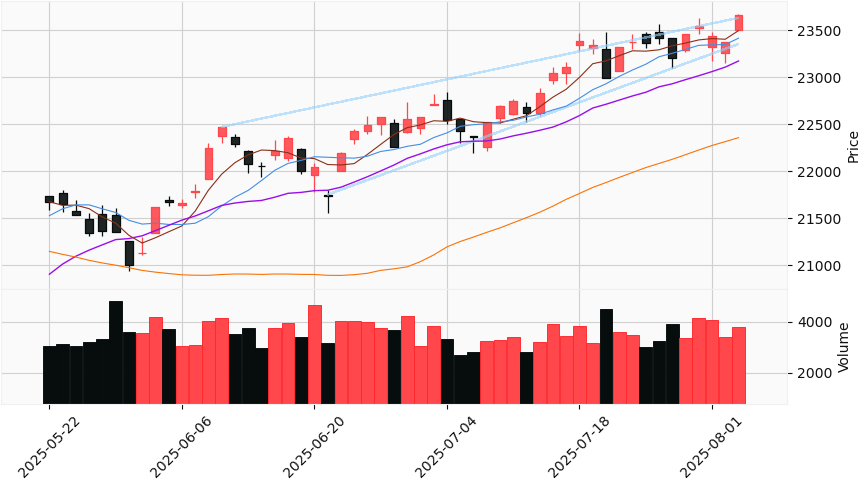

In [6]:
# 盤後：上升楔形繪製
image = mysys.DrawOnKlineChart('TAIEX','2025-05-22','2025-08-05',line_drawing_callback)
display(image)

> **盤後**：量化技術分析  

解盤內容：


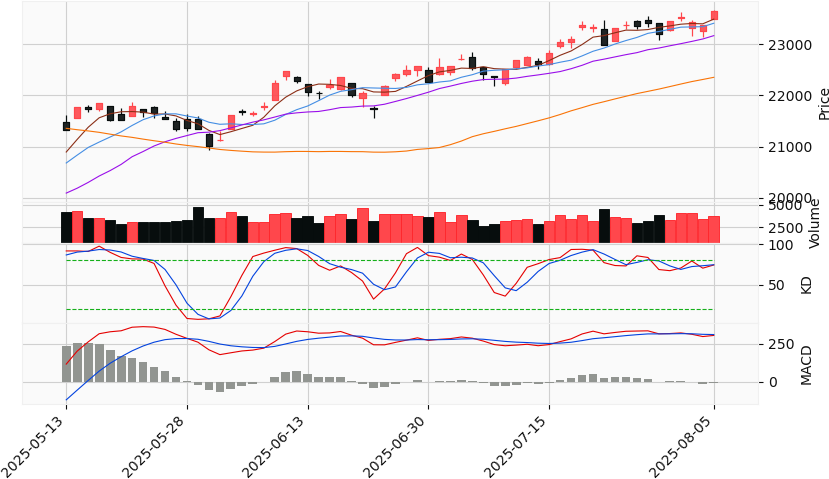

技術分析工具,解盤內容
Ｋ線／Ｋ棒,紡錘線 : 2025-07-31 十字線 : 2025-07-31
Ｋ線圖,中期為高位階 長期為高位階
成交量,價量關係：未至大量門檻（成交量 ＝ 3800.74億元 ，十日均量 ＝ 3598.56億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.24。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線上揚、240日線上揚，長期翻多
ＫＤ指標,於2025-08-04死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-07-28該周在超買區。
整體評價,技術分析 價格趨勢 從K線圖來看，近期價格呈現上漲趨勢。短期移動平均線（5日和10日）均向上，並且位於中期移動平均線（20日和60日）之上，顯示出多頭排列的格局。 價量關係 成交量在價格上漲時有所增加，顯示出價量配合良好，支持上漲趨勢。這表明市場對於目前的上漲趨勢有較強的信心。 支撐與壓力 支撐位置可參考20日移動平均線，約在23000點附近。壓力位置則可觀察近期高點，約在23500點左右。 KD指標解讀 KD指標顯示K線和D線均在高檔區域，且K線略高於D線，顯示出多頭趨勢。然而，指標接近超買區，需留意可能的回檔風險。 MACD指標解讀 MACD指標中，DIF線位於MACD線之上，且灰色柱體（OSC）為正值，顯示出多頭趨勢。這進一步支持價格的上漲動能。 綜合評價 整體來看，市場目前處於上漲趨勢，價量配合良好，技術指標支持多頭格局。然而，由於KD指標接近超買區，短期內需留意可能的回檔風險。建議投資者在持有多頭部位時，設置適當的停利和停損點，以應對潛在的市場波動。


In [7]:
# 盤後：加權指數解盤
stock_analysis(analysis,'TAIEX')

* 櫃買指數  

> **盤中**：櫃買指數盤整區小突破，挑戰短線前高，今天中小型股應該也會不錯。
> 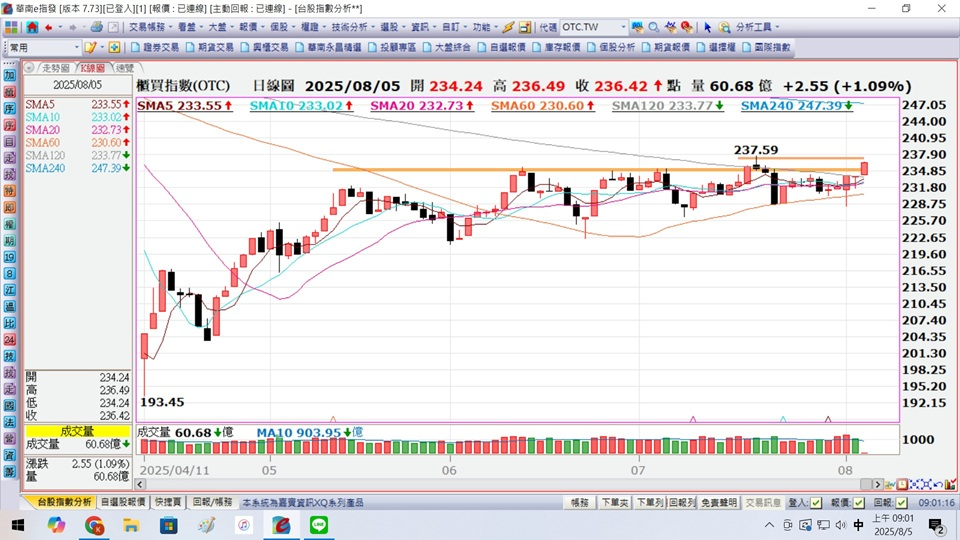  

In [8]:
# 盤整區間
def line_drawing_callback( range_prices) :

    seq_of_seq_of_points = []
    linewidths           = []
    colors               = []
    
    # 設定壓力線一
    resistance_line_start_date  = '2025-05-13'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-07-18']['Close']
    seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)])
    linewidths.append(1.0)
    colors.append('xkcd:yellow orange')

    # 設定壓力線二
    resistance_line_start_date  = '2025-07-16'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-07-18']['High']
    seq_of_seq_of_points.append([(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)])
    linewidths.append(0.8)
    colors.append('xkcd:yellow orange')
    
    return seq_of_seq_of_points,linewidths,colors

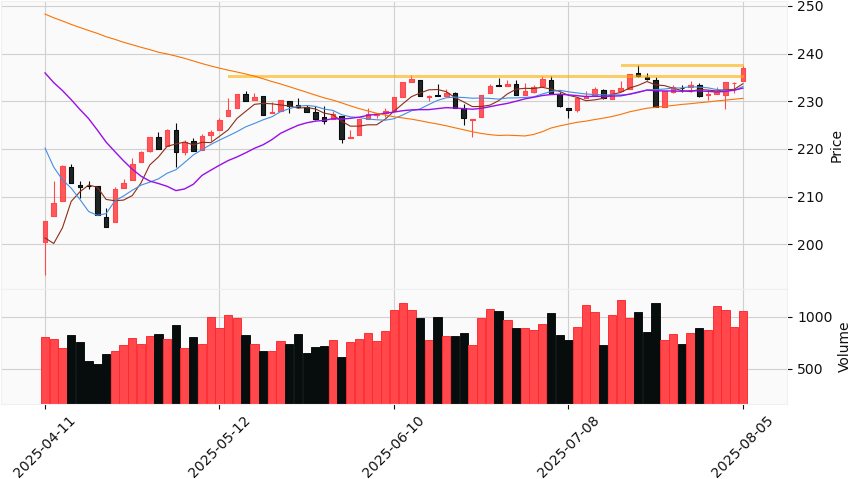

In [9]:
# 盤前：箱型區間繪製
image = mysys.DrawOnKlineChart('TPEx','2025-04-11','2025-08-05',line_drawing_callback)
display(image)

> **盤後**：量化技術分析  

解盤內容：


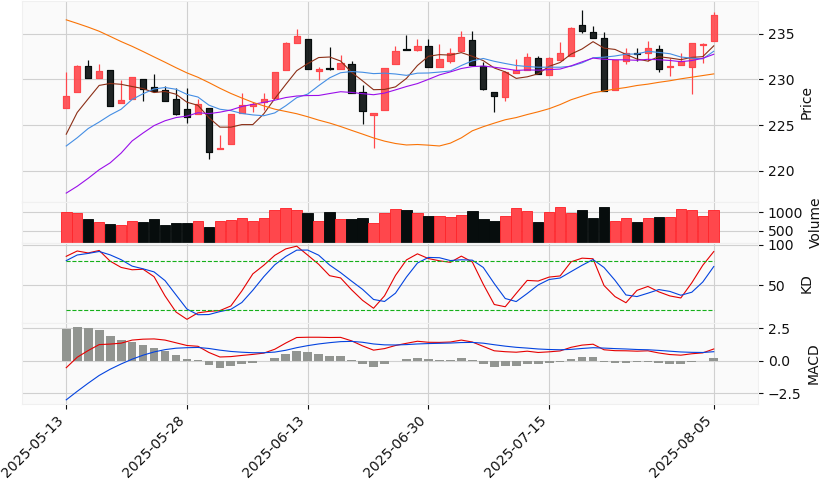

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-30 十字線 : 2025-07-30 , 2025-08-04 鎚子線／吊人線 : 2025-08-04 孕育線／懷抱線 : 2025-07-30 , 2025-08-04"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1056.91億元 ，十日均量 ＝ 906.86億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-08-01黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-07-21當周死亡交叉。
整體評價,價格趨勢 目前價格呈現上漲趨勢，近期K線多為紅K，顯示多頭力量較強。短期移動平均線（5日、10日）向上穿越中期移動平均線（20日、60日），顯示短期趨勢向好。 價量關係 成交量在近期上漲時有所增加，顯示價量配合良好，支持上漲趨勢。這表明市場對於價格上漲的信心增強。 支撐與壓力 目前支撐位可參考20日移動平均線附近，約在230點左右。壓力位則在近期高點附近，約在235點以上。 KD指標解讀 KD指標顯示K線已進入超買區域，且高於D線，顯示短期內可能有回檔壓力。然而，K線持續高於D線，顯示多頭仍有優勢。 MACD指標解讀 MACD指標中，DIF線高於MACD線，且灰色柱體由負轉正，顯示多頭動能增強，支持上漲趨勢。 綜合評價 綜合以上分析，目前市場呈現上漲趨勢，價量配合良好，短期內可能會有回檔壓力，但整體多頭趨勢仍然強勁。建議投資者可考慮在支撐位附近進行佈局，並注意超買區域的回檔風險，適時進行停利操作。


In [10]:
# 盤後：櫃買指數解盤
stock_analysis(analysis,'TPEx')

### 個股解盤  

* 飛宏(2457)  
  看法：迷你底部雛形，尚未突破。  

> **盤後**：量化技術分析  

解盤內容：


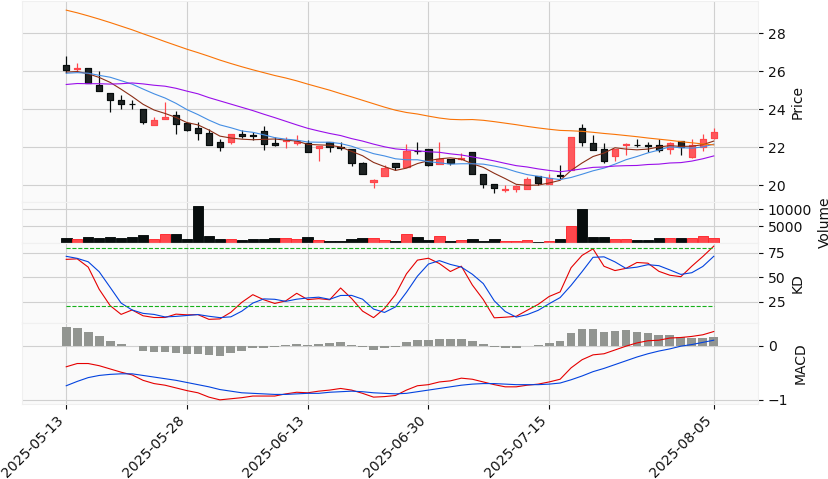

技術分析工具,解盤內容
Ｋ線／Ｋ棒,
Ｋ線圖,中期為中位階 長期為低位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1594張 ，十日均量 ＝ 1331張）
型態,反轉型態之下降楔形，型態範圍由2025-02-20開始到2025-07-10結束。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線下彎，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-08-01黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。
整體評價,價格趨勢分析 近期股價呈現反彈走勢，K線圖顯示價格已突破短期移動平均線（5日和10日），並接近20日移動平均線。60日移動平均線仍在上方，顯示中期壓力尚未完全解除。 價量關係 成交量在價格上漲時有所增加，顯示多頭動能增強，價量配合良好。這表明市場對於近期的反彈趨勢有一定的信心。 支撐與壓力判斷 - 支撐位：短期支撐位可參考10日移動平均線附近。 - 壓力位：中期壓力位在60日移動平均線附近，若能有效突破，將有助於進一步上漲。 KD指標解讀 KD指標顯示K線已進入超買區域，且高於D線，顯示短期內可能有回檔壓力。然而，若能持續在高位徘徊，則顯示多頭趨勢仍有延續的可能。 MACD指標解讀 MACD指標中，DIF線在MACD線之上，且灰色柱體（OSC）持續增長，顯示多頭動能增強，短期內仍有上漲空間。 綜合評價 整體來看，股價短期內呈現反彈走勢，成交量配合良好，顯示多頭動能增強。然而，需注意KD指標進入超買區域，短期內可能面臨回檔壓力。建議投資者在接近60日移動平均線時謹慎操作，若能有效突破，則可考慮加碼進場。若出現回檔，則可在支撐位附近尋求買入機會。


In [11]:
stock_analysis(analysis,'2457')

> **盤後**：底部反轉交易策略分析  
> 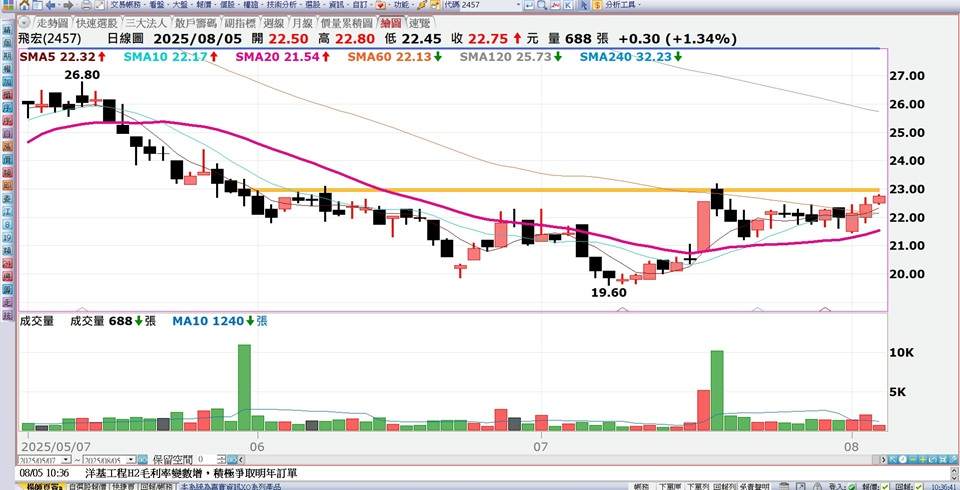  

In [12]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-05-28'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-07-18']['Open']

    # 設定底部到頸線差距
    bottom_date  = '2025-07-08'
    bottom_price = range_prices.loc['2025-07-08']['Open']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)],
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

估算目標價為25.90元


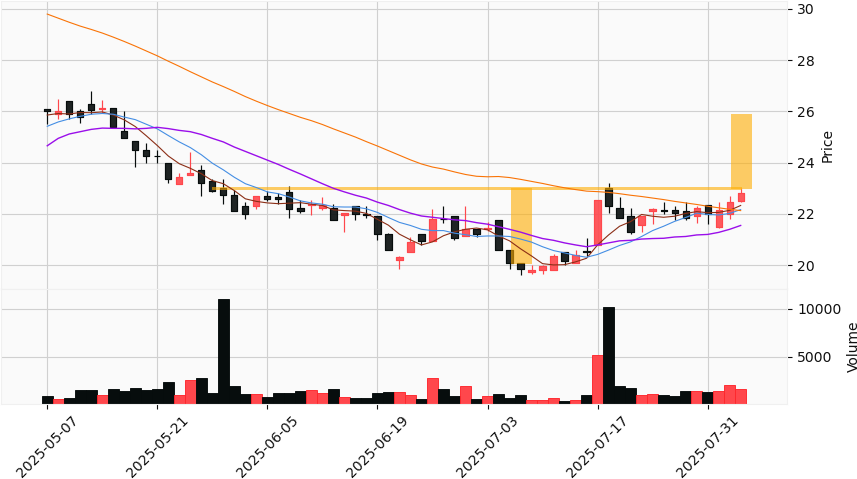

In [13]:
image = mysys.DrawOnKlineChart('2457','2025-05-07','2025-08-05',line_drawing_callback)
display(image)

籌碼面：  
法人小買(+449)：外資小買(+415)、投信中立(0)、自營小買(+34)。  
主力小買(+180)。  
分公司買賣家數差集中(+26)。  
融資減(-208)、融券增(+19)。  